# Ransomware Detection and Prevention

**Section 4 of the ML in Cyber Security assignment (25 marks)**

This notebook builds and compares two models for classifying Windows executables as malicious or benign based on the sequence of Windows API calls each one made during dynamic analysis, and is designed to run in **Google Colab**: you upload the dataset CSV yourself when prompted, no Kaggle API or credential setup needed.

1. **Classic Machine Learning:** SVM (Support Vector Machine) over a "bag of API calls" feature vector
2. **Deep Learning:** LSTM over the raw, ordered API call sequence

**Dataset:** Windows API Call Sequence Dataset - 3,940 samples, each recording up to the first 152 Windows API calls made by an executable (already integer-encoded into 308 API call categories, IDs 0-307), plus a `hash` identifier and a binary `malware` label (`1` = malicious, `0` = benign). Most samples actually used far fewer than 152 calls (62.9 on average) and are padded out to that fixed width - this is handled explicitly in Section 2 below. The label distinguishes malicious software generally (as curated by the dataset's authors under the ransomware/malware behavioural-analysis umbrella referenced in the assignment brief) from benign software - not every malicious sample here is necessarily ransomware specifically, which is discussed further in the Discussion section.

**Why two different feature representations for the two models:** the classic ML model is given a "bag of API calls" (a count of how often each API category appears in the sequence) - a fixed-length, order-independent feature vector, which is the standard feature-extraction technique for this kind of data with classic ML models. The LSTM instead consumes the actual ordered sequence of API call IDs through an embedding layer, since modelling call order over time is exactly what an LSTM is for, and is explicitly what the assignment brief asks the deep learning model to do ("model system behavior over time"). This is discussed further in Section 5 below.

**Before running:** have `new_dataset.csv` ready on your computer (already present in this folder's `data/`). You do **not** need to upload it into Colab yourself first - the data-loading cell below will open Colab's upload dialog automatically if it can't find the file.

In [18]:
import os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Google Colab:", IN_COLAB)
print("Working directory:", os.getcwd())

Running in Google Colab: True
Working directory: /content


In [19]:
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = "outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Load Dataset (Google Colab Upload)

This notebook does **not** download anything itself. It looks for `new_dataset.csv` in the most common places a file ends up after uploading it in Colab:

- `data/new_dataset.csv` (if you created a `data` folder in the Files sidebar and uploaded into it)
- `new_dataset.csv` directly in `/content` (the default location if you just drag-and-drop the file into the Files sidebar root)

**If it can't find the file anywhere, the cell below will automatically open Colab's upload dialog** so you can pick the CSV from your computer - no need to fix folders/paths yourself. At only about 1.5MB, this dataset uploads almost instantly.

Note: anything uploaded this way only lives for the current Colab session/runtime - if the runtime restarts or disconnects, you'll need to upload again.

In [20]:
EXPECTED_FILENAME = "new_dataset.csv"
CANDIDATE_DIRS = ["data", ".", "/content", "/content/data"]


def find_dataset_path():
    checked_dirs = []
    for directory in CANDIDATE_DIRS:
        if directory in checked_dirs:
            continue
        checked_dirs.append(directory)
        exact_path = os.path.join(directory, EXPECTED_FILENAME)
        if os.path.exists(exact_path):
            return exact_path

    for directory in checked_dirs:
        if os.path.isdir(directory):
            csv_files = sorted(glob.glob(os.path.join(directory, "*.csv")))
            if len(csv_files) == 1:
                return csv_files[0]

    return None


def load_api_call_dataset():
    dataset_path = find_dataset_path()

    if dataset_path is None and IN_COLAB:
        print(
            f"Could not find '{EXPECTED_FILENAME}' in {CANDIDATE_DIRS}. "
            "Opening the upload dialog -- please choose the CSV file from your computer..."
        )
        from google.colab import files
        files.upload()  # uploaded file(s) are saved into the current working directory
        dataset_path = find_dataset_path()

    if dataset_path is None:
        raise FileNotFoundError(
            f"Could not find the dataset. Expected '{EXPECTED_FILENAME}' in one of: {CANDIDATE_DIRS}.\n"
            "In Google Colab: re-run this cell to trigger the upload dialog, or manually upload the "
            "CSV via the Files sidebar (into '/content' or a 'data' subfolder), then re-run this cell.\n"
            "See README.md for details."
        )

    print(f"Loading dataset from '{dataset_path}' ...")
    return pd.read_csv(dataset_path)


df = load_api_call_dataset()
print("Shape:", df.shape)
df.head()

Loading dataset from './new_dataset.csv' ...
Shape: (3940, 177)


,hash,malware,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,50,214,70.0,89.0,128.0,198.0,39.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,156,266,70.0,225.0,119.0,123.0,117.0,214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,266,225,198.0,39.0,71.0,158.0,65.0,194.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e0f3e4d5f50afd9c31e51dd9941c5a52d57c7c524f5d11...,0,158,50,118.0,235.0,274.0,117.0,283.0,215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ec2b6d29992f13e74015ff0b129150b4afae15c593e4b7...,0,50,82,274.0,108.0,16.0,283.0,215.0,208.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Overview and Column Selection

The raw CSV has 177 columns: `hash` (a unique sample identifier, not predictive), `malware` (the binary label), 152 sequence-position columns named `"0"` through `"151"`, and 22 further trailing columns that are empty for every row except one (that one row happens to have a longer recorded sequence than every other sample; it is truncated to the same 152 positions as everything else for consistency).

**Within the 152 sequence columns themselves, most samples do not use all 152 positions.** Only 3 of the 3,940 rows have a value in every one of them - the real, recorded API call sequence is usually much shorter (62.9 calls on average, ranging from 2 to 152), and the CSV pads every row out to a fixed 152-column width with empty cells after the real sequence ends. Pandas reads those empty cells as missing values (`NaN`), which would make casting the columns straight to an integer type fail. They are filled in with a dedicated padding sentinel, `PAD_VALUE = 308` - one more than the highest real API call ID - before converting to integers. `0` cannot be used as the padding marker here, since `0` is already a real, frequently used API call ID in this data, not a placeholder for "no call". The padding sentinel is treated as its own distinct category everywhere below (the SVM's bag-of-calls feature excludes it explicitly; the LSTM's embedding table is sized to include it).

Only the columns actually needed are kept: the 152 sequence columns (as the feature source) and `malware` (as the label). `hash` and the trailing empty columns are dropped.

In [21]:
SEQ_LEN = 152
SEQ_COLS = [str(i) for i in range(SEQ_LEN)]
NUM_API_CATEGORIES = 308  # real API call IDs range 0-307
PAD_VALUE = 308  # sentinel for "no call recorded" at this sequence position
VOCAB_SIZE = NUM_API_CATEGORIES + 1  # +1 for the padding sentinel; used by the LSTM's embedding

df = df[SEQ_COLS + ["malware"]].copy()

n_missing = int(df[SEQ_COLS].isna().sum().sum())
print(f"Missing (padded) sequence positions filled with PAD_VALUE={PAD_VALUE}: {n_missing}")

df[SEQ_COLS] = df[SEQ_COLS].fillna(PAD_VALUE).astype("int32")
df["malware"] = df["malware"].astype("int32")

print("Shape after column selection:", df.shape)
print("\nLabel distribution before deduplication (0 = benign, 1 = malware):")
print(df["malware"].value_counts())

Missing (padded) sequence positions filled with PAD_VALUE=308: 350911
Shape after column selection: (3940, 153)

Label distribution before deduplication (0 = benign, 1 = malware):
malware
1    2626
0    1314
Name: count, dtype: int64


## 3. Remove Duplicate Samples (Prevent Train/Test Leakage)

Checking the raw data directly showed that only 2,298 of the 3,940 API call sequences are actually unique - about 49% of rows share their full 152-call sequence with at least one other row (one sequence alone repeats 164 times). This is expected for this kind of data: many samples are variants of the same underlying malware family, or repackaged copies of the same benign executable, and both tend to produce identical API call fingerprints at this level of granularity. Only one duplicate sequence (12 rows) has inconsistent labels across its copies, which is a negligible amount of label noise rather than a sign of a broader data quality problem.

As in every other section of this assignment, exact-duplicate rows are removed before splitting into train/test, for the same reason: without this, copies of the same sequence could end up in both the training and test sets, letting a model "recognize" a duplicate instead of genuinely generalizing. A useful side effect here is that deduplication also happens to leave the two classes almost perfectly balanced (about 50/50), simplifying the rest of the pipeline.

In [22]:
n_before = len(df)
df = df.drop_duplicates(subset=SEQ_COLS).reset_index(drop=True)
n_after = len(df)

print(f"Removed {n_before - n_after} duplicate sequences ({n_before} -> {n_after} rows).")
print("\nLabel distribution after deduplication (0 = benign, 1 = malware):")
print(df["malware"].value_counts())

Removed 1642 duplicate sequences (3940 -> 2298 rows).

Label distribution after deduplication (0 = benign, 1 = malware):
malware
1    1156
0    1142
Name: count, dtype: int64


## 4. Exploratory Data Analysis

Class balance, and two simple behavioural indicators derived from each sample's (real, non-padded) API call sequence: how many *distinct* API calls it uses, and how long the real sequence actually is - split by class.

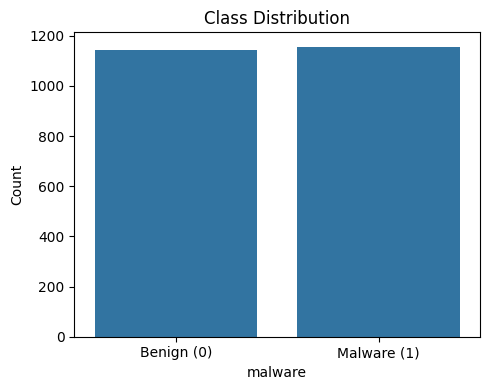

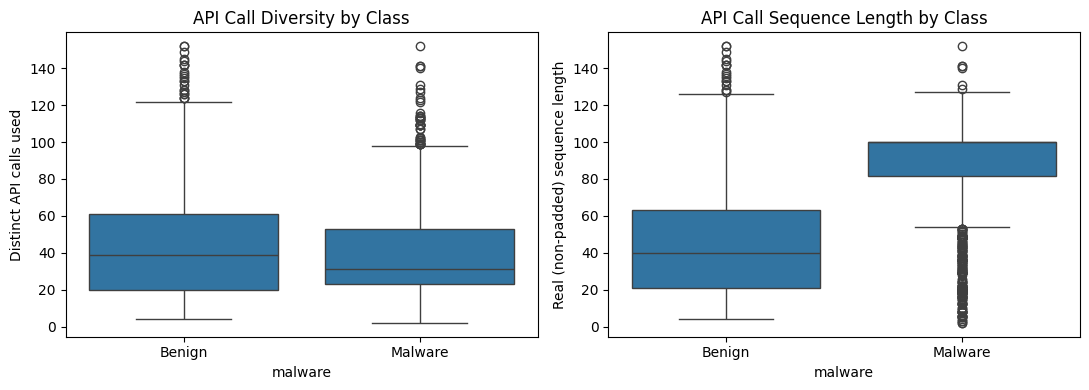

malware
1    1156
0    1142
Name: count, dtype: int64

Real sequence length: mean = 65.88685813751088 , min = 2 , max = 152


In [23]:
plt.figure(figsize=(5, 4))
sns.countplot(x="malware", data=df)
plt.xticks([0, 1], ["Benign (0)", "Malware (1)"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=150)
plt.show()

df["sequence_length"] = (df[SEQ_COLS] != PAD_VALUE).sum(axis=1)
df["n_unique_calls"] = df[SEQ_COLS].apply(
    lambda row: row[row != PAD_VALUE].nunique(), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(x="malware", y="n_unique_calls", data=df, ax=axes[0])
axes[0].set_xticklabels(["Benign", "Malware"])
axes[0].set_ylabel("Distinct API calls used")
axes[0].set_title("API Call Diversity by Class")

sns.boxplot(x="malware", y="sequence_length", data=df, ax=axes[1])
axes[1].set_xticklabels(["Benign", "Malware"])
axes[1].set_ylabel("Real (non-padded) sequence length")
axes[1].set_title("API Call Sequence Length by Class")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "api_behaviour_by_class.png"), dpi=150)
plt.show()

print(df["malware"].value_counts())
print("\nReal sequence length: mean =", df["sequence_length"].mean(), ", min =", df["sequence_length"].min(), ", max =", df["sequence_length"].max())

## 5. Feature Extraction

The raw values in the sequence columns are **category codes** (which API was called), not magnitudes - API call ID 200 is not "bigger" than API call ID 100 in any meaningful sense, and the padding sentinel (`PAD_VALUE = 308`) is not a real call at all. Feeding these numbers directly into a distance- or margin-based classic ML model like an SVM would implicitly (and wrongly) treat them as ordered/continuous, and would also treat "no call" as if it were just another API. Two different, purpose-built representations are built instead:

- **Bag of API calls (for the SVM):** each sample's *real* (non-padded) calls are converted into a 308-dimensional count vector - how many times each API category appears anywhere in the sequence, regardless of order. The padding sentinel is explicitly excluded from this count, since it carries no behavioural information. Two extra engineered features are appended: the number of distinct API calls used, and the real sequence length (both from the EDA above). This is the standard feature-extraction technique for this kind of data with classic ML models, and directly captures "key ransomware behaviour patterns" as the assignment describes: which system operations a program relies on, how heavily, and how long it ran for.
- **Raw ordered sequence (for the LSTM):** the LSTM instead receives the padded sequence exactly as recorded (real calls followed by the padding sentinel), with each of the 309 possible values (308 real categories plus the padding sentinel) looked up in a learned embedding table - `VOCAB_SIZE = 309` sizes that table correctly. This preserves the calling *order*, which a bag-of-calls representation deliberately discards, and is what the assignment means by using an LSTM "to model system behavior over time." The model is not told which positions are padding versus real calls (no explicit masking is used); it simply has to learn that the padding token carries no useful signal, which is discussed as a limitation later.

In [24]:
sequence_array = df[SEQ_COLS].to_numpy(dtype="int32")

bag_of_calls = np.zeros((len(df), NUM_API_CATEGORIES), dtype="float32")
for row_idx in range(sequence_array.shape[0]):
    real_calls = sequence_array[row_idx]
    real_calls = real_calls[real_calls != PAD_VALUE]
    counts = np.bincount(real_calls, minlength=NUM_API_CATEGORIES)
    bag_of_calls[row_idx] = counts

engineered_features = df[["n_unique_calls", "sequence_length"]].to_numpy(dtype="float32")
X_bow = np.hstack([bag_of_calls, engineered_features])
X_seq = sequence_array
y = df["malware"].to_numpy()

print("Bag-of-calls feature matrix shape (SVM input):", X_bow.shape)
print("Raw sequence matrix shape (LSTM input):", X_seq.shape)

Bag-of-calls feature matrix shape (SVM input): (2298, 310)
Raw sequence matrix shape (LSTM input): (2298, 152)


## 6. Train / Test Split

A single 80/20 stratified split is computed once, by index, and then applied to both feature representations - so the SVM and the LSTM are evaluated on exactly the same held-out samples, making the final comparison a fair one. `StandardScaler` (fit on the training split only) is applied to the bag-of-calls features for the SVM; the raw sequence fed to the LSTM does not need scaling, since it is looked up in an embedding table rather than used as a numeric magnitude.

In [25]:
indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=SEED, stratify=y
)

X_bow_train, X_bow_test = X_bow[train_idx], X_bow[test_idx]
X_seq_train, X_seq_test = X_seq[train_idx], X_seq[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train size: {len(train_idx)}, Test size: {len(test_idx)}")

scaler = StandardScaler()
X_bow_train_scaled = scaler.fit_transform(X_bow_train)
X_bow_test_scaled = scaler.transform(X_bow_test)

joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))

Train size: 1838, Test size: 460


['outputs/models/scaler.joblib']

## 7. Evaluation Helper

Both models below are evaluated the same way, so the plotting/reporting function is defined once here: a classification report (precision/recall/F1, the specific metrics the assignment names for this section), a confusion matrix, and an ROC curve.

In [26]:
def evaluate_model(y_true, y_pred, y_proba, model_name, filename_prefix):
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malware"], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Benign", "Malware"], yticklabels=["Benign", "Malware"],
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"{filename_prefix}_confusion_matrix.png"), dpi=150)
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"{filename_prefix}_roc_curve.png"), dpi=150)
    plt.show()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
    }

## 8. Classic Machine Learning - SVM

An RBF-kernel `SVC` is trained on the standardized bag-of-calls features. `probability=True` enables the probability estimates needed for the ROC curve, and `class_weight="balanced"` accounts for the (small) remaining class imbalance after deduplication.

=== SVM (bag of API calls) ===
              precision    recall  f1-score   support

      Benign       0.95      0.92      0.93       229
     Malware       0.92      0.95      0.94       231

    accuracy                           0.93       460
   macro avg       0.94      0.93      0.93       460
weighted avg       0.94      0.93      0.93       460



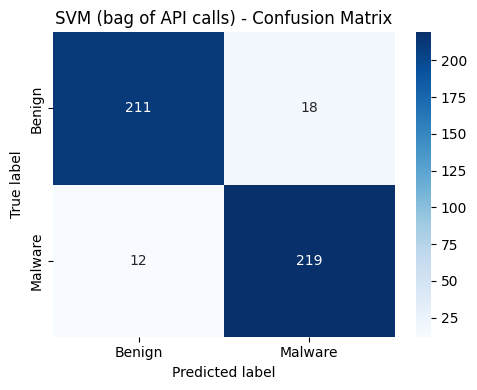

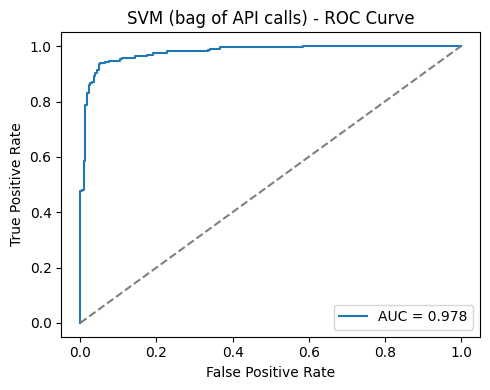

Saved SVM model to outputs/models


In [27]:
svm_model = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED)
svm_model.fit(X_bow_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_bow_test_scaled)
y_proba_svm = svm_model.predict_proba(X_bow_test_scaled)[:, 1]

results_svm = evaluate_model(y_test, y_pred_svm, y_proba_svm, "SVM (bag of API calls)", "svm")

joblib.dump(svm_model, os.path.join(MODELS_DIR, "svm.joblib"))
print("Saved SVM model to", MODELS_DIR)

## 9. Deep Learning - LSTM

The raw, ordered API call sequence (including the padding sentinel where a sample's real sequence was shorter than 152) is fed through an `Embedding` layer sized to `VOCAB_SIZE = 309` (308 real API call categories plus the padding sentinel), turning each value into a learned dense vector, and then an `LSTM`, which reads the sequence in order and can pick up on call-order patterns the bag-of-calls representation cannot see at all.

In [28]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=SEQ_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_seq_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.5051 - loss: 0.6938 - val_accuracy: 0.4638 - val_loss: 0.6961
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5134 - loss: 0.6930 - val_accuracy: 0.4638 - val_loss: 0.6963
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5077 - loss: 0.6930 - val_accuracy: 0.4638 - val_loss: 0.6961
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.4949 - loss: 0.6932 - val_accuracy: 0.4638 - val_loss: 0.6955
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5102 - loss: 0.6926 - val_accuracy: 0.4638 - val_loss: 0.6967
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.5070 - loss: 0.6928 - val_accuracy: 0.4638 - val_loss: 0.6956
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5198 - loss: 0.6929 - val_accuracy: 0.4638 - val_loss: 0.6953
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.5000 - loss: 0.6934 - val_accuracy: 0.4638 -

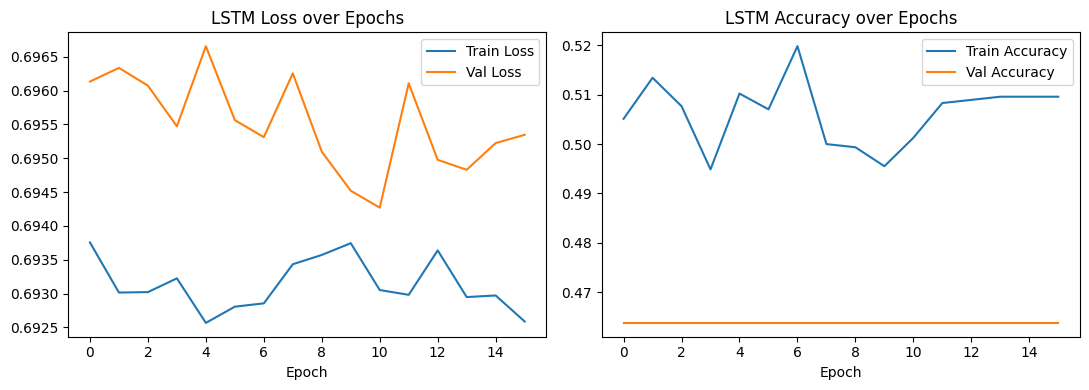

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
=== LSTM (ordered API call sequence) ===
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       229
     Malware       0.50      1.00      0.67       231

    accuracy                           0.50       460
   macro avg       0.25      0.50      0.33       460
weighted avg       0.25      0.50      0.34       460



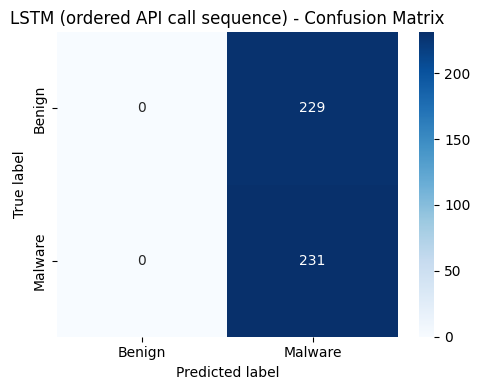

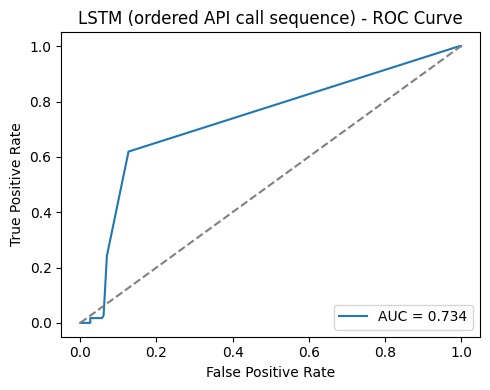

Saved LSTM model to outputs/models


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("LSTM Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("LSTM Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "lstm_training_curves.png"), dpi=150)
plt.show()

y_proba_lstm = lstm_model.predict(X_seq_test).ravel()
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int)

results_lstm = evaluate_model(y_test, y_pred_lstm, y_proba_lstm, "LSTM (ordered API call sequence)", "lstm")

lstm_model.save(os.path.join(MODELS_DIR, "lstm_model.keras"))
print("Saved LSTM model to", MODELS_DIR)

## 10. Model Comparison

Accuracy, precision, recall, F1-score, and ROC-AUC for both models side by side.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
SVM (bag of API calls),0.934783,0.924051,0.948052,0.935897,0.978449
LSTM (ordered sequence),0.502174,0.502174,1.000000,0.668596,0.734088


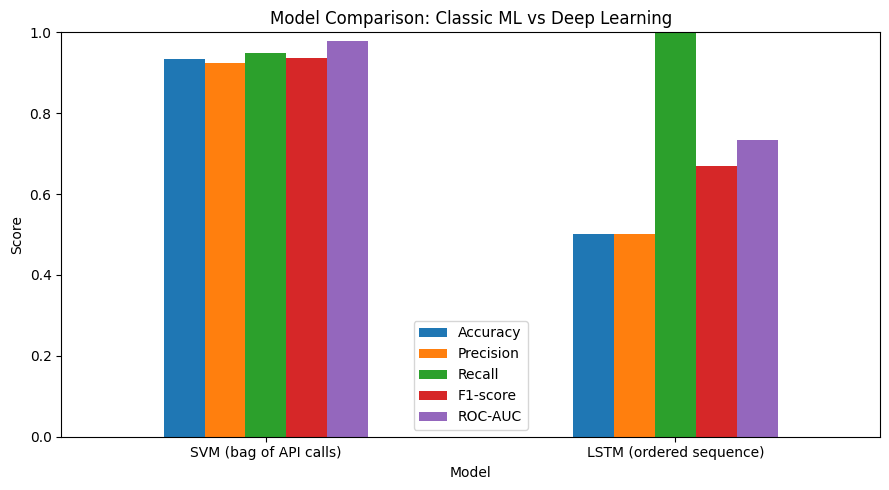

Saved comparison table to outputs/model_comparison.csv


In [30]:
results = pd.DataFrame([
    {"Model": "SVM (bag of API calls)", **results_svm},
    {"Model": "LSTM (ordered sequence)", **results_lstm},
]).set_index("Model")

display(results)

results.plot(kind="bar", figsize=(9, 5), ylim=(0, 1))
plt.title("Model Comparison: Classic ML vs Deep Learning")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_comparison.png"), dpi=150)
plt.show()

results.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"))
print("Saved comparison table to", os.path.join(OUTPUT_DIR, "model_comparison.csv"))

## 11. Discussion

**Findings.** Fill this in after running the notebook with the actual numbers from the comparison table above - e.g. which model achieved higher precision/recall/F1, and whether preserving call order (LSTM) actually helped over the order-independent bag-of-calls representation (SVM) for this particular dataset.

**Cybersecurity implications.** In malware/ransomware triage, a false negative (malware classified as benign) is far more costly than a false positive (a benign file flagged for review), since a missed ransomware sample can encrypt a victim's files before anyone notices. Recall on the malware class should be weighted at least as heavily as overall accuracy or precision when choosing which model, and which decision threshold, to deploy.

**Limitations.**
- The label distinguishes malware from benign software generally; the dataset is not exclusively ransomware-labelled, so results here should be read as "general Windows malware detection from API call behaviour" rather than a ransomware-specific benchmark, even though ransomware families are presumably well represented among the malware samples.
- Only up to the first 152 API calls of each execution are captured, and only 3 of the 3,940 samples actually reached that limit - most used far fewer (62.9 calls on average). So truncation only matters for a small minority of long-running samples; for everyone else, the limitation is not how much of the trace is missing, but that this is a snapshot of early-execution behaviour only. Ransomware in particular is known to sometimes delay its malicious behaviour specifically to evade early-behaviour detection, and a longer capture window would be needed to test for that.
- The bag-of-calls representation discards all ordering and timing information by design; it cannot distinguish "call A then call B" from "call B then call A", even though such distinctions can matter behaviourally (e.g. reading a file before versus after modifying permissions on it).
- The LSTM is not given explicit masking to distinguish real calls from the padding sentinel that fills out shorter sequences; it has to learn from data alone that the padding token carries no useful signal. An explicit masking layer would likely help, particularly since the average real sequence (63 calls) is well under half of the fixed 152-length input.
- No hyperparameter tuning (e.g. SVM's C/gamma, LSTM's embedding size/units/learning rate) was performed; both models use reasonable defaults.
- With only 2,298 samples after deduplication, both models - especially the LSTM - are trained on a fairly small dataset by deep learning standards, which limits how much a more complex architecture could realistically be expected to help.

**Potential improvements.**
- Use API call **n-grams** (pairs or triples of consecutive calls) instead of single-call counts as an intermediate feature-extraction step for the classic ML model, to partially recover some order information without a full sequence model.
- Add an explicit Keras `Masking` layer (or pack/pad sequences with proper masking support) so the LSTM is told directly which positions are padding, rather than having to infer it.
- Try a bidirectional LSTM, or add an attention layer, to see whether the model benefits from looking at the sequence from both directions or focusing on specific critical calls.
- If a version of this dataset with explicit ransomware-vs-other-malware-vs-benign labels is available, repeat this as a 3-class problem to test whether ransomware specifically is separable from other malware families using the same features.
- Capture and use a longer call sequence (beyond the first 152 calls) if the underlying data collection supports it, to test whether later-stage behavioural signals (e.g. mass file encryption calls) improve detection further - this would matter most for the rare samples that already use the full 152-call window.